# Vine distributions: a copula and its margins

A vine copula models dependence on the copula scale. It lives on $[0, 1]^d$ and
says nothing about where the data are. Sklar's theorem supplies the other half —
one univariate distribution per variable — and puts the two together:

$$
F(\mathbf{x}) = C\bigl(F_1(x_1), \ldots, F_d(x_d)\bigr), \qquad
\log f(\mathbf{x}) = \log c\bigl(F_1(x_1), \ldots, F_d(x_d)\bigr)
  + \sum_{j=1}^{d} \log f_j(x_j).
$$

`pyvinecopulib.core.Vinedist` is that factorization as an object: a vine copula
plus one margin per variable, exposing `pdf` / `cdf` / `simulate` /
`rosenblatt` on the **data** scale. `pyvinecopulib.margins` supplies the margins
— kernel-density, empirical, parametric with family selection — and coerces
distribution objects from other libraries.

Two chores disappear along the way. Evaluating a joint density used to mean
writing $\log c(\mathbf{u}) + \sum_j \log f_j(x_j)$ out by hand and keeping the
marginal transform in step with the marginal densities. And a variable with atoms
used to mean assembling the copula's input by hand — the `np.hstack` of
left-limit columns that `04_discrete_variables.ipynb` still does explicitly. Both
are now internal to the object, and neither branches on the variable type.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st

import pyvinecopulib as pv
from pyvinecopulib.core import MarginBase
from pyvinecopulib.margins import (
  EmpiricalMargin,
  Kde1dMargin,
  MarginSelector,
  ParametricMargin,
  as_margin,
)

SEED = 20240818
pd.set_option("display.max_colwidth", 60)  # so a rejection reason fits

## A synthetic portfolio

Four dependent variables drawn through a Gaussian copula, so every margin is
known in closed form: an average claim `size` (gamma), a risk `score` (normal),
a loss `ratio` on the unit interval (beta), and a claim count `claims`
(Poisson). Knowing the truth is the point — it lets the estimates below be
checked rather than admired.

In [2]:
n = 800
rng = np.random.default_rng(SEED)
corr = np.array(
  [
    [1.00, 0.70, 0.35, 0.45],
    [0.70, 1.00, 0.30, 0.40],
    [0.35, 0.30, 1.00, 0.55],
    [0.45, 0.40, 0.55, 1.00],
  ]
)
z = rng.multivariate_normal(np.zeros(4), corr, size=n)

true_margins = {
  "size": st.gamma(2.5, scale=1.5),
  "score": st.norm(70.0, 12.0),
  "ratio": st.beta(2.0, 5.0),
  "claims": st.poisson(2.5),
}
names = list(true_margins)
x = np.column_stack(
  [true_margins[nm].ppf(st.norm.cdf(z[:, j])) for j, nm in enumerate(names)]
)
cont = x[:, :3]  # the three continuous columns

pd.DataFrame(x, columns=names).describe().round(2)

,size,score,ratio,claims
count,800.00,800.00,800.00,800.00
mean,3.74,70.16,0.29,2.52
std,2.41,11.51,0.15,1.57
min,0.17,34.36,0.01,0.00
25%,2.00,62.47,0.17,1.00
50%,3.24,69.64,0.27,2.00
75%,5.12,78.19,0.39,3.00
max,16.12,107.61,0.80,8.00


## The default path

`Vinedist.from_data` is the two-step estimator of Joe and Xu (1996): fit each
margin from its own column, transform to the copula scale, fit the vine there.
The default margin is `Kde1dMargin`, a boundary-corrected kernel density, so
nothing has to be assumed about marginal shape. Start with the three continuous
columns; the count comes back further down.

In [3]:
dist = pv.Vinedist.from_data(cont)
print(dist)
print(f"var_types: {dist.var_types}")
print(f"log-likelihood: {float(dist.loglik(cont)):.1f}")
print(dist.copula)

Vinedist(dim=3, margins=[kde1d, kde1d, kde1d])
var_types: ['c', 'c', 'c']
log-likelihood: -4079.9
<pyvinecopulib.core.Vinecop> Vinecop model with 3 variables
tree edge conditioned variables conditioning variables var_types   family rotation parameters  df  tau 
   1    1                  3, 1                             c, c Gaussian        0       0.35 1.0 0.23 
   1    2                  2, 1                             c, c Gaussian        0       0.70 1.0 0.49 
   2    1                  3, 2                      1      c, c Gaussian        0       0.12 1.0 0.08 



### `logpdf` is the Sklar factorization, and nothing else

The copula term and the marginal log-densities are added in log space — for even
a moderate $d$ the product of marginal densities underflows long before the sum
of their logs does. The result is the value a careful hand computation gives, to
the last bit rather than to a tolerance.

In [4]:
u = dist.marginal_cdf(cont)
by_hand = np.log(np.asarray(dist.copula.pdf(u)))
for j, margin in enumerate(dist.margins):
  by_hand = by_hand + np.log(np.asarray(margin.pdf(cont[:, j])))

gap = np.abs(by_hand - dist.logpdf(cont)).max()
print(f"max |by hand - logpdf|: {gap:.1e}")

max |by hand - logpdf|: 0.0e+00


### Simulating on the data scale

`simulate` draws from the copula and pushes each column through its margin's
quantile function, so the draws come back on the original scale.

One caveat belongs to the kernel-density default rather than to the vine: an
unbounded `Kde1dMargin` pads its fitted grid past the data, and for a variable
that cannot be negative that puts mass where nothing can occur. Bounds are worth
stating whenever they are known — `size` is positive and `ratio` is a
proportion. A mapping addresses those two by name and leaves `score` on the
default.

In [5]:
unbounded_draws = dist.simulate(n, seeds=[1, 2, 3])

bounded = pv.Vinedist.from_data(
  cont,
  margins={
    "size": Kde1dMargin(xmin=0.0),
    "ratio": Kde1dMargin(xmin=0.0, xmax=1.0),
  },
  names=names[:3],
)
draws = bounded.simulate(n, seeds=[1, 2, 3])

header = f"{'column':>7} {'observed min':>13} {'unbounded':>10} {'bounded':>8}"
print(header)
for j, nm in enumerate(names[:3]):
  print(
    f"{nm:>7} {cont[:, j].min():13.3f} "
    f"{unbounded_draws[:, j].min():10.3f} {draws[:, j].min():8.3f}"
  )

 column  observed min  unbounded  bounded
   size         0.171     -0.653    0.007
  score        34.361     32.423   32.468
  ratio         0.008     -0.030    0.003


The pair plot puts the draws next to the data: marginal histograms on top,
pairwise scatter plots underneath. The margins are nearly guaranteed to line up,
because each was fitted to that column; the scatter panels are where the vine
has to earn it.

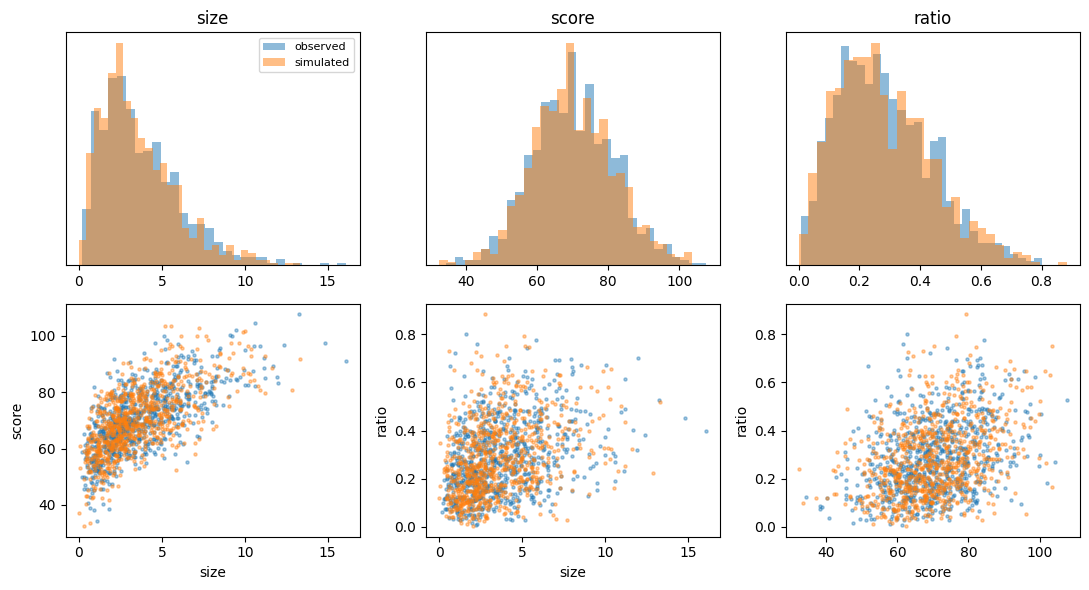

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for j, nm in enumerate(names[:3]):
  ax = axes[0, j]
  ax.hist(cont[:, j], bins=30, density=True, alpha=0.5, label="observed")
  ax.hist(draws[:, j], bins=30, density=True, alpha=0.5, label="simulated")
  ax.set_title(nm)
  ax.set_yticks([])
  if j == 0:
    ax.legend(fontsize=8)
for ax, (i, j) in zip(axes[1], [(0, 1), (0, 2), (1, 2)]):
  ax.scatter(cont[:, i], cont[:, j], s=5, alpha=0.4)
  ax.scatter(draws[:, i], draws[:, j], s=5, alpha=0.4)
  ax.set_xlabel(names[i])
  ax.set_ylabel(names[j])
fig.tight_layout()

### The Rosenblatt transform as a goodness-of-fit check

`rosenblatt` maps the data through the fitted model to $d$ variables that are
independent uniforms exactly when the model is correct — margins and copula
together. That makes it the natural diagnostic for a vine *distribution*, where
a copula-scale check would leave the marginal half untested. `inverse_rosenblatt`
goes back, and lands on the original scale.

Read the numbers as a screen for gross misfit rather than as a test: these are
the same observations both halves of the model were fitted to, so the
Kolmogorov-Smirnov p-values below are optimistic. `score`, at $D = 0.051$, is the
largest departure of the three.

In [7]:
w = np.asarray(bounded.rosenblatt(cont))
print("uniformity of each Rosenblatt coordinate")
for j, nm in enumerate(names[:3]):
  result = st.kstest(w[:, j], "uniform")
  print(f"  {nm:>7}  D = {result.statistic:.3f}   p = {result.pvalue:.2f}")

taus = [
  abs(float(pv.utils.wdm(w[:, i], w[:, j], "kendall")))
  for i in range(3)
  for j in range(i + 1, 3)
]
print(f"largest |Kendall tau| between coordinates: {max(taus):.3f}")

back = np.asarray(bounded.inverse_rosenblatt(w))
print(f"inverse round trip, max error: {np.abs(back - cont).max():.1e}")

uniformity of each Rosenblatt coordinate
     size  D = 0.028   p = 0.56
    score  D = 0.051   p = 0.03
    ratio  D = 0.017   p = 0.98
largest |Kendall tau| between coordinates: 0.009
inverse round trip, max error: 3.5e-07


## Margins from other ecosystems

`as_margin` presents a distribution object from another library as a margin. It
is idempotent — anything this library made comes back unchanged — and it wraps
what it recognizes rather than duck-typing it, because matching the member
*names* of the contract is not the same as matching its semantics.

SciPy's modern discrete classes are the case in point. They carry `pdf`, `cdf`
and `icdf`, so a `runtime_checkable` protocol check passes, and their `pdf` is
the Lebesgue density — which is $+\infty$ at every atom. The mass lives on
`pmf`, and that is what the wrapper routes to.

The left limit is handled per generation. SciPy's legacy `cdf` is a genuine step
function, so $F(k - 1)$ is read straight off the lattice; the modern `cdf`
interpolates between atoms, where stepping back a lattice point would land inside
the jump, so the mass is subtracted instead.

In [8]:
legacy = st.gamma(2.5, scale=1.5)  # a frozen legacy distribution
margin = as_margin(legacy)
print(margin, margin.support)
print(f"as_margin is idempotent: {as_margin(margin) is margin}")

counts = as_margin(st.poisson(2.5))
k = np.arange(6.0)
mass = np.asarray(counts.pdf(k))
print(f"pdf is the mass:  {np.allclose(mass, st.poisson.pmf(k, 2.5))}")
print(
  f"jump is the mass: {np.allclose(counts.cdf(k) - counts.cdf_left(k), mass)}"
)

as_margin(gamma, var_type='c') (0.0, inf)
as_margin is idempotent: True
pdf is the mass:  True
jump is the mass: True


SciPy's new distribution infrastructure is recognized as well. The two cells
below are guarded, because `scipy.stats.Normal` and the new-API discrete classes
arrived in different SciPy releases.

In [9]:
if hasattr(st, "Normal"):
  modern = as_margin(st.Normal(mu=70.0, sigma=12.0))
  print(modern, modern.var_type, modern.support)

if hasattr(st, "Binomial"):
  raw = st.Binomial(n=10, p=0.3)
  print(f"raw .pdf at the atoms: {raw.pdf(k[:4])}")
  print(
    f"as_margin(...).pdf:    {np.asarray(as_margin(raw).pdf(k[:4])).round(4)}"
  )

as_margin(Normal, var_type='c') c (-inf, inf)
raw .pdf at the atoms: [inf inf inf inf]
as_margin(...).pdf:    [0.0282 0.1211 0.2335 0.2668]


Passing the data-generating margins in directly gives the model no marginal
estimation to do at all: a margin that is already fitted is left alone, so fixed
and estimated margins mix freely in one call. Here the true margins are worth
under two log-likelihood units against the kernel ones, which is the useful thing
to know about the nonparametric default at $n = 800$.

In [10]:
exact = pv.Vinedist.from_data(
  cont,
  margins=[true_margins["size"], true_margins["score"], true_margins["ratio"]],
)
print(exact)
print(f"log-likelihood, true margins:   {float(exact.loglik(cont)):.1f}")
print(f"log-likelihood, kernel margins: {float(bounded.loglik(cont)):.1f}")

Vinedist(dim=3, margins=[gamma, norm, beta])
log-likelihood, true margins:   -4079.0
log-likelihood, kernel margins: -4080.6


## Parametric margins and family selection

`ParametricMargin` wraps one SciPy family fitted by maximum likelihood.
`MarginSelector` fits several and keeps the best by AIC, BIC or AICc; the
selector is itself a margin, forwarding evaluation to the winner, so it drops
into a `Vinedist` exactly like a fixed family.

The candidate set is **curated**, not "everything SciPy ships", and that is a
statistical decision rather than a convenience. A blind sweep promotes families
that misstate their own support above the truth, because a log-likelihood is only
comparable across families that are all normalized over the same set. The
curated set is grouped by support instead — real line, positive, unit interval, a
caller-supplied interval, counts — with `loc` (and `scale` where the support is
known) pinned. Pinning pays twice: it removes the boundary escapes, and it
removes a parameter that the criterion would otherwise charge for.

Nothing is dropped silently. A candidate that fails to fit, or that fits to
something inadmissible, still gets a row in `report_` with the reason it lost.

In [11]:
selectors = [MarginSelector(criterion="bic", name=nm) for nm in names[:3]]
selected = pv.Vinedist.from_data(cont, margins=selectors)
print(selected)
for margin in selected.margins:
  winner = margin.selected_
  shown = ", ".join(
    f"{nm}={val:.3f}"
    for nm, val in zip(winner.parameter_names, winner.parameters)
  )
  print(f"  {margin.name:>7}  {margin.family_name:<8}  {shown}")

Vinedist(dim=3, margins=[gamma, norm, beta])
     size  gamma     a=2.359, loc=0.000, scale=1.587
    score  norm      loc=70.160, scale=11.506
    ratio  beta      a=2.180, b=5.465, loc=0.000, scale=1.000


All three true families come back, with parameters close to the gamma(2.5, scale
1.5), normal(70, 12) and beta(2, 5) they were drawn from. The full table for
`size` shows what they beat.

In [12]:
report = pd.DataFrame(
  [row for margin in selected.margins for row in margin.report_]
)
shown = ["family", "n_parameters", "loglik", "bic", "status"]
(
  report[report["column"] == "size"]
  .sort_values("bic")[shown]
  .round(2)
  .reset_index(drop=True)
)

,family,n_parameters,loglik,bic,status
0,gamma,2.0,-1722.46,3458.29,selected
1,weibull_min,2.0,-1727.92,3469.22,ok
2,skewnorm,3.0,-1725.17,3470.40,ok
3,gumbel_r,2.0,-1743.27,3499.91,ok
4,lognorm,2.0,-1751.76,3516.88,ok
5,invgauss,2.0,-1778.09,3569.55,ok
6,logistic,2.0,-1821.45,3656.27,ok
7,t,3.0,-1819.48,3659.01,ok
8,norm,2.0,-1838.23,3689.83,ok
9,laplace,2.0,-1845.74,3704.84,ok


Across all three variables, only the rows that are not a plain `ok` need
reading: the three winners, and the Student $t$ fits whose degrees of freedom ran
off to a normal limit and were rejected for it rather than being allowed to win
by rounding error.

In [13]:
interesting = report["status"] != "ok"
(
  report.loc[interesting, ["column", "family", "n_parameters", "bic", "status"]]
  .round(2)
  .reset_index(drop=True)
)

,column,family,n_parameters,bic,status
0,size,gamma,2.0,3458.29,selected
1,score,norm,2.0,6192.30,selected
2,score,t,3.0,6198.99,"degenerate parameter df=3669.61, outside (0.0, 200.0)"
3,ratio,t,3.0,-704.06,"degenerate parameter df=1.80033e+09, outside (0.0, 200.0)"
4,ratio,beta,2.0,-812.85,selected


The claim about misstated support is checkable, so here it is. `vonmises` is
periodic: it advertises the whole real line, and its density integrates to about
16 there rather than to 1. Fitted to the gamma-distributed `size` column it beats
the true family by 572 AIC units, which is why it — and every other family with
the same defect — is excluded from the automatic candidate set while staying
reachable by name.

In [14]:
def aic(margin, data):
  loglik = float(np.sum(margin.logpdf(data)))
  return -2.0 * loglik + 2.0 * margin.n_parameters


size = cont[:, 0]
gamma_fit = ParametricMargin("gamma", floc=0.0).fit(size)
vonmises_fit = ParametricMargin("vonmises").fit(size)
print(f"gamma    AIC {aic(gamma_fit, size):9.1f}")
print(f"vonmises AIC {aic(vonmises_fit, size):9.1f}")

wide = np.linspace(-50.0, 50.0, 200_001)
print(
  f"vonmises density over [-50, 50]: {np.trapezoid(vonmises_fit.pdf(wide), wide):.2f}"
)
print(
  f"gamma density over [-50, 50]:    {np.trapezoid(gamma_fit.pdf(wide), wide):.2f}"
)

gamma    AIC    3448.9
vonmises AIC    2876.4
vonmises density over [-50, 50]: 15.94
gamma density over [-50, 50]:    1.00


Among the admissible candidates the competition is much closer. The two next-best
by BIC are `weibull_min`, anchored at the origin like the winner, and `skewnorm`,
which lives on the real line but is skewed enough to compete — and pays for a
third parameter to do it.

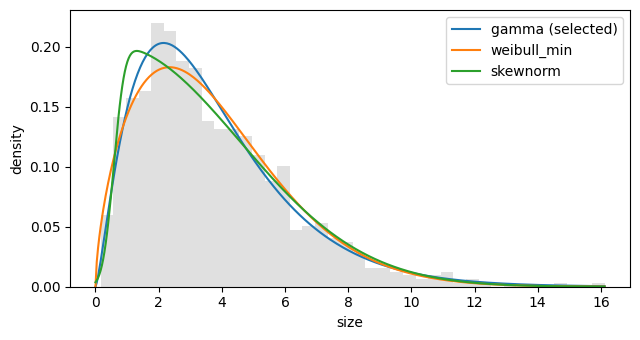

In [15]:
grid = np.linspace(0.0, size.max(), 400)
candidates = {
  "gamma (selected)": gamma_fit,
  "weibull_min": ParametricMargin("weibull_min", floc=0.0).fit(size),
  "skewnorm": ParametricMargin("skewnorm").fit(size),
}

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(size, bins=40, density=True, alpha=0.4, color="0.7")
for label, candidate in candidates.items():
  ax.plot(grid, candidate.pdf(grid), label=label)
ax.set_xlabel("size")
ax.set_ylabel("density")
ax.legend()
fig.tight_layout()

## The identity worth knowing

Fitting a `Vinecop` to `to_pseudo_obs(x)` — the workflow every earlier notebook
uses — is a `Vinedist` with `EmpiricalMargin` margins (also spelled
`margins="empirical"`). That helper is exactly $n / (n + 1)$ times the empirical
distribution function, and `EmpiricalMargin` is that function as a distribution,
so the copula sees identical input and the two fitted copulas agree bit for bit.

The joint log-densities do not agree, and should not. An empirical margin has no
Lebesgue density; its `pdf` is the mass $1 / (n + 1)$ carried by each
observation. The joint log-density therefore sits below the copula's log-density
by the constant $-d \log(n + 1)$, which for $d = 3$ and $n = 800$ is
$-3 \log 801$. It is a quantity to compare across models on the same data, not a
density on the original scale.

In [16]:
empirical = pv.Vinedist.from_data(cont, margins=EmpiricalMargin())
u_ranks = np.asarray(pv.to_pseudo_obs(cont))
copula_only = pv.Vinecop.from_data(u_ranks)

print(
  "same structure: "
  f"{np.array_equal(empirical.copula.structure.matrix, copula_only.structure.matrix)}"
)
print(
  "identical copula densities: "
  f"{np.array_equal(empirical.copula.pdf(u_ranks), copula_only.pdf(u_ranks))}"
)

offset = empirical.logpdf(cont) - np.log(np.asarray(copula_only.pdf(u_ranks)))
print(f"offset:        [{offset.min():.6f}, {offset.max():.6f}]")
print(f"-d log(n + 1): {-3.0 * np.log(n + 1.0):.6f}")

same structure: True
identical copula densities: True
offset:        [-20.057583, -20.057583]
-d log(n + 1): -20.057583


## Discrete and mixed margins

Bring the count column back. Two things make a mixed vector work without a
single branch on the variable type.

A margin's `pdf` is a density with respect to *its own* reference measure:
Lebesgue for a continuous variable, counting measure at an atom. So
$\log f = \log c(\mathbf{u}) + \sum_j \log \mathrm{pdf}_j$ holds verbatim, the
copula factor being normalized by the marginal masses.

And a variable with atoms needs its left limit $F(x^-)$ as well as $F(x)$,
because the distribution function alone does not identify the copula at a jump.
`Vinedist` assembles the compact $(n, d + k)$ layout — one column per variable,
then one left-limit column per variable with atoms, in variable order — and
`copula_data` exposes it as a static method for anyone who wants to fit their own
copula first and wrap it afterwards.

The count margin here is a `MarginSelector` again. It infers that non-negative
integer data are counts and switches to the count group, whose log-likelihoods
are never compared against the continuous families.

In [17]:
count_selector = MarginSelector(name="claims")
mixed = pv.Vinedist.from_data(
  x,
  margins=[
    Kde1dMargin(xmin=0.0),
    Kde1dMargin(),
    Kde1dMargin(xmin=0.0, xmax=1.0),
    count_selector,
  ],
)
print(mixed)
print(f"var_types: {mixed.var_types}")

layout = pv.Vinedist.copula_data(mixed.margins, x)
print(f"copula-scale layout: {layout.shape} = 4 variables + 1 left limit")
print(
  f"left limit never above the cdf: {bool(np.all(layout[:, 4] <= layout[:, 3]))}"
)

by_hand = np.log(np.asarray(mixed.copula.pdf(layout)))
for j, margin in enumerate(mixed.margins):
  by_hand = by_hand + np.log(np.asarray(margin.pdf(x[:, j])))
print(f"max |by hand - logpdf|: {np.abs(by_hand - mixed.logpdf(x)).max():.1e}")

Vinedist(dim=4, margins=[kde1d, kde1d, kde1d, poisson])
var_types: ['c', 'c', 'c', 'd']
copula-scale layout: (800, 5) = 4 variables + 1 left limit
left limit never above the cdf: True
max |by hand - logpdf|: 0.0e+00


`geom` is parameterized as a number of trials, so it cannot host a zero — and it
is rejected with that reason on the record rather than quietly skipped. `nbinom`,
which covers the zero-inclusive geometric, stays in and loses to the true Poisson
by a little more than the two AIC units its extra parameter costs.

The count families have no closed-form fitter in SciPy, so they go through
`scipy.stats.fit`, whose global search runs unseeded: `nbinom`'s last digits move
between runs, though the ranking does not.

In [18]:
pd.DataFrame(count_selector.report_)[
  ["family", "n_parameters", "loglik", "aic", "status"]
].round(1)

,family,n_parameters,loglik,aic,status
0,poisson,1.0,-1459.3,2920.7,selected
1,nbinom,2.0,-1459.3,2922.7,ok
2,geom,1.0,-inf,inf,"support (1, inf) does not contain the data range [0, 8]"


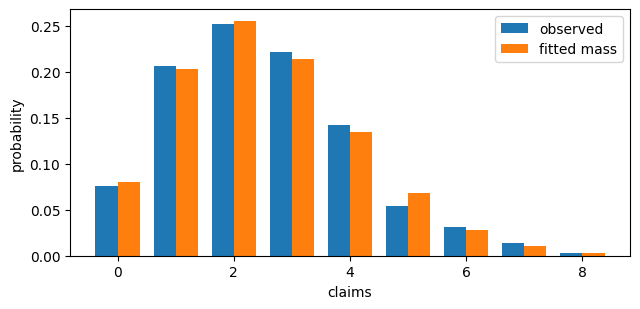

In [19]:
atoms = np.arange(9.0)
fitted_mass = np.asarray(mixed.margins[3].pdf(atoms))
observed = np.bincount(x[:, 3].astype(int), minlength=atoms.size) / n

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(atoms - 0.19, observed[: atoms.size], width=0.38, label="observed")
ax.bar(atoms + 0.19, fitted_mass, width=0.38, label="fitted mass")
ax.set_xlabel("claims")
ax.set_ylabel("probability")
ax.legend()
fig.tight_layout()

Simulating through a count margin lands on the lattice, because the margin's
quantile function does. `cdf` is estimated by Monte Carlo, so it takes `N` and
`seeds` and passes them on to the copula.

In [20]:
mixed_draws = mixed.simulate(500, seeds=[7, 8, 9])
lattice = np.array_equal(mixed_draws[:, 3], np.round(mixed_draws[:, 3]))
print(f"count draws land on the lattice: {lattice}")

quantiles = np.linspace(0.1, 0.9, 5)
corner = np.column_stack([np.quantile(x[:, j], quantiles) for j in range(4)])
values = np.asarray(mixed.cdf(corner, N=20_000, seeds=[1, 2, 3]))
for q, value in zip(quantiles, values):
  print(f"  all margins at the {q:.0%} quantile: F = {value:.4f}")

count draws land on the lattice: True
  all margins at the 10% quantile: F = 0.0118
  all margins at the 30% quantile: F = 0.0835
  all margins at the 50% quantile: F = 0.1974
  all margins at the 70% quantile: F = 0.4192
  all margins at the 90% quantile: F = 0.7581


## A custom margin

A margin is also its own estimator: hyperparameters go in `__init__`, and `fit`
estimates the rest in place and returns `self`. Subclassing `MarginBase` needs
only `pdf` and `cdf` — `icdf` follows by monotone bisection over `support`, and
`logpdf`, `cdf_left`, `loglik` and `simulate` follow from those. `simulate` is
the one that needs a little more: the base class has no array namespace of its
own to draw from, so it delegates to a `_simulate_uniform` hook.

The example is a two-component normal mixture, the standard answer to a bimodal
column and something no curated family can represent.

In [21]:
class NormalMixture(MarginBase[np.ndarray]):
  """A two-component normal mixture, fitted by EM."""

  def __init__(self, weight=None, mu=None, sigma=None, n_iter=200):
    self.weight, self.mu, self.sigma, self.n_iter = weight, mu, sigma, n_iter

  @property
  def is_fitted(self):
    return self.weight is not None

  @property
  def family_name(self):
    return "normal-mixture"

  @property
  def n_parameters(self):
    return 5.0

  def _parts(self):
    weights = np.array([self.weight, 1.0 - self.weight])
    return weights, np.asarray(self.mu, float), np.asarray(self.sigma, float)

  def pdf(self, x):
    weights, mu, sigma = self._parts()
    z = np.asarray(x, float)[..., None]
    return (weights * st.norm.pdf(z, mu, sigma)).sum(axis=-1)

  def cdf(self, x):
    weights, mu, sigma = self._parts()
    z = np.asarray(x, float)[..., None]
    return (weights * st.norm.cdf(z, mu, sigma)).sum(axis=-1)

  def fit(self, x, *, weights=None):
    data = np.asarray(x, float).ravel()
    lo, hi = np.quantile(data, [0.25, 0.75])
    self.weight, self.mu, self.sigma = 0.5, (lo, hi), (data.std(),) * 2
    for _ in range(self.n_iter):
      prior, mu, sigma = self._parts()
      joint = prior * st.norm.pdf(data[:, None], mu, sigma)
      posterior = joint / joint.sum(axis=1, keepdims=True)
      mass = posterior.sum(axis=0)
      mu = (posterior * data[:, None]).sum(axis=0) / mass
      spread = (posterior * (data[:, None] - mu) ** 2).sum(axis=0) / mass
      self.weight = mass[0] / data.size
      self.mu, self.sigma = tuple(mu), tuple(np.sqrt(spread))
    return self

  def _simulate_uniform(self, n, seeds):
    return pv.utils.simulate_uniform(n, 1, seeds=seeds).ravel()

  def __repr__(self):
    if not self.is_fitted:
      return "NormalMixture(unfitted)"
    return (
      f"NormalMixture(weight={self.weight:.3f}, "
      f"mu=({self.mu[0]:.2f}, {self.mu[1]:.2f}), "
      f"sigma=({self.sigma[0]:.2f}, {self.sigma[1]:.2f}))"
    )

A margin whose parameters are supplied at construction is already fitted, so the
inherited `icdf` works straight away — here to generate a bimodal column, coupled
to `score` through a latent normal so that there is dependence for the vine to
find. Fitting a fresh instance to that column recovers what it was drawn from.

In [22]:
mixture = NormalMixture(weight=0.4, mu=(-2.0, 2.0), sigma=(0.6, 1.0))
noise = np.random.default_rng(SEED + 1).standard_normal(n)
latent = 0.6 * z[:, 1] + np.sqrt(1.0 - 0.6**2) * noise
spread = mixture.icdf(st.norm.cdf(latent))  # inherited bisection

fitted = NormalMixture().fit(spread)
print(f"drawn from  {mixture}")
print(f"fitted      {fitted}")

probs = np.linspace(0.01, 0.99, 99)
round_trip = np.abs(fitted.cdf(fitted.icdf(probs)) - probs).max()
print(f"cdf(icdf(p)), max error: {round_trip:.1e}")
drawn = fitted.simulate(2_000, seeds=[SEED])
print(
  f"simulate: mean {drawn.mean():.3f} against {spread.mean():.3f} in the data"
)

drawn from  NormalMixture(weight=0.400, mu=(-2.00, 2.00), sigma=(0.60, 1.00))
fitted      NormalMixture(weight=0.420, mu=(-1.97, 1.97), sigma=(0.59, 0.98))
cdf(icdf(p)), max error: 4.4e-16
simulate: mean 0.278 against 0.312 in the data


Scored on the same criterion as the built-in families, the mixture wins by close
to 500 AIC units — which is the point of being able to add one.

mixture              AIC    2976.2
norm                 AIC    3474.1  (best curated)


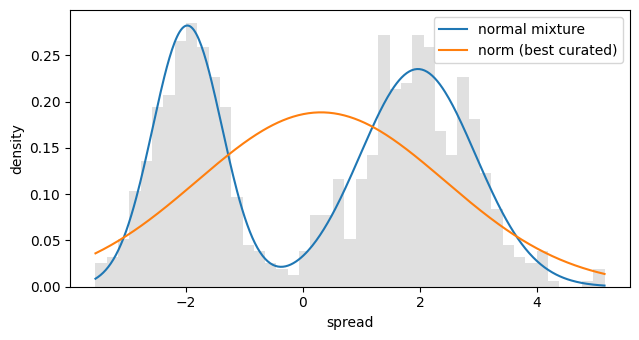

In [23]:
curated = MarginSelector(name="spread").fit(spread)
print(f"mixture              AIC {aic(fitted, spread):9.1f}")
print(
  f"{curated.family_name:<20} AIC {aic(curated, spread):9.1f}  (best curated)"
)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(spread, bins=45, density=True, alpha=0.4, color="0.7")
line = np.linspace(spread.min(), spread.max(), 400)
ax.plot(line, fitted.pdf(line), label="normal mixture")
ax.plot(line, curated.pdf(line), label=f"{curated.family_name} (best curated)")
ax.set_xlabel("spread")
ax.set_ylabel("density")
ax.legend()
fig.tight_layout()

Dropping it into a `Vinedist` needs nothing further — an unfitted instance is
fitted from its column like any other margin.

In [24]:
pair = np.column_stack([cont[:, 1], spread])
joint = pv.Vinedist.from_data(pair, margins=[Kde1dMargin(), NormalMixture()])
print(joint)
print(f"log-likelihood: {float(joint.loglik(pair)):.1f}")
print(joint.copula)

Vinedist(dim=2, margins=[kde1d, normal-mixture])
log-likelihood: -4398.0
<pyvinecopulib.core.Vinecop> Vinecop model with 2 variables
tree edge conditioned variables conditioning variables var_types   family rotation parameters  df  tau 
   1    1                  2, 1                             c, c Gaussian        0       0.59 1.0 0.40 



## What's next

- The scikit-learn estimators are `Vinedist` underneath: `VineDensity` and
  `VineRegressor` publish the fitted model as `distribution_`, and any
  selector's table as `selection_report_`. See `08_sklearn_estimators.ipynb`.
- `pyvinecopulib.torch` ships the same pair on tensors — `TorchMargin` and
  `TorchVinedist` — for GPU placement and autograd; see
  `09_torch_backend.ipynb`.
- For custom pair copulas and non-simplified vines, which is the dependence half
  of the same picture, see `10_extending_pyvinecopulib.ipynb`.